### Exploração inicial `SLCE3`. Quais relações podemos identificar?

#### Apresentação e tratamento

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Carrega o dataset
df = pd.read_csv('SLCE3.csv')

# Exibe as primeiras 5 linhas do DataFrame
print("Primeiras 5 linhas do DataFrame:")
print(df.head())

# Exibe informações gerais sobre o DataFrame
print("\nInformações gerais do DataFrame:")
print(df.info())

# Verifica se há valores negativos nas colunas relevantes
columns_to_check = ['Close', 'Open', 'High', 'Low', 'Volume']
for column in columns_to_check:
    if (df[column] < 0).any():
        print(f"\nHá valores negativos na coluna '{column}'.")
    else:
        print(f"Não há valores negativos na coluna '{column}'.")

Primeiras 5 linhas do DataFrame:
         Date     Close      High       Low      Open   Volume
0  2018-01-02  3.077934  3.103537  2.972182  2.972182  1227908
1  2018-01-03  3.104650  3.215968  3.067915  3.077933  2494536
2  2018-01-04  3.092405  3.198157  3.055670  3.104650  2957724
3  2018-01-05  3.150290  3.166988  3.069028  3.138046  2140248
4  2018-01-08  3.133592  3.183685  3.112442  3.150290  1613172

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738 entries, 0 to 1737
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1738 non-null   object 
 1   Close   1738 non-null   float64
 2   High    1738 non-null   float64
 3   Low     1738 non-null   float64
 4   Open    1738 non-null   float64
 5   Volume  1738 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 81.6+ KB
None
Não há valores negativos na coluna 'Close'.
Não há valores negativos na coluna 'Open'

#### Adicionando colunas de valores futuros

In [30]:
sns.set_style("whitegrid")

print("\nEstatísticas descritivas do DataFrame (com 'Close_Open_Diff'):")
print(df.describe())

df['Close_1d_fut'] = df['Close'].shift(-1)
df['Close_3d_fut'] = df['Close'].shift(-3)
df['Close_7d_fut'] = df['Close'].shift(-7)
df['Close_15d_fut'] = df['Close'].shift(-15)
df['Close_30d_fut'] = df['Close'].shift(-30)

print("\nPrimeiras linhas com colunas de fechamento futuro:")
print(df[['Close', 'Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']].head(35))

df_process = df.dropna(subset=['Close_1d_fut', 'Close_3d_fut', 'Close_7d_fut', 'Close_15d_fut', 'Close_30d_fut']).copy()




Estatísticas descritivas do DataFrame (com 'Close_Open_Diff'):
             Close         High          Low         Open        Volume
count  1738.000000  1738.000000  1738.000000  1738.000000  1.738000e+03
mean     12.853513    13.075743    12.651012    12.864267  3.029539e+06
std       5.343477     5.411924     5.279755     5.346681  1.646280e+06
min       3.077934     3.103537     2.972182     2.972182  0.000000e+00
25%       7.535588     7.698608     7.380720     7.525807  1.936355e+06
50%      15.115987    15.484339    14.797091    15.086999  2.659459e+06
75%      17.593738    17.889725    17.371993    17.623443  3.652664e+06
max      22.668043    22.707364    21.952418    22.648385  1.532296e+07

Primeiras linhas com colunas de fechamento futuro:
       Close  Close_1d_fut  Close_3d_fut  Close_7d_fut  Close_15d_fut  \
0   3.077934      3.104650      3.150290      3.215968       3.336190   
1   3.104650      3.092405      3.133592      3.205949       3.484243   
2   3.092405     

#### Valor de fechamento em função do tempo.

In [31]:
df_process['Date'] = pd.to_datetime(df_process['Date'])
df_process.set_index('Date', inplace=True)



#### Analise aprofundada de 2021

In [32]:
# # Garante que o índice é DatetimeIndex
if not isinstance(df_process.index, pd.DatetimeIndex):
	df_process.index = pd.to_datetime(df_process.index)


#### Adicionando variaveis dicotômicas para 2021-05-05 e 2022-02-07

In [33]:
# Criação da variável dicotômica categórica
# 0: antes de 2021-05-05
# 1: entre 2021-05-05 e 2022-02-07 
# 2: após 2022-02-07
df_process['dummy_period'] = 0
df_process.loc[df_process.index >= pd.to_datetime('2021-05-05'), 'dummy_period'] = 1
df_process.loc[df_process.index >= pd.to_datetime('2022-02-07'), 'dummy_period'] = 2

print(f"Distribuição da variável dummy_period:")
print(df_process['dummy_period'].value_counts().sort_index())

Distribuição da variável dummy_period:
dummy_period
0    824
1    190
2    694
Name: count, dtype: int64


#### Modelo de Regressão Logística

Vamos construir um modelo de regressão logística para prever se o preço de fechamento futuro será maior que o preço de fechamento atual. Para isso, vamos:

1. Criar variáveis binárias para os diferentes horizontes temporais (3, 7, 15 e 30 dias)
2. Usar as variáveis `Low`, `High`, `Open` e `dummy_period` como preditores
3. Avaliar o desempenho dos modelos para cada horizonte temporal

In [34]:
# Criando variáveis target binárias para regressão logística
# 1 = preço futuro > preço atual, 0 = preço futuro <= preço atual

df_process['target_3d'] = (df_process['Close_3d_fut'] > df_process['Close']).astype(int)
df_process['target_7d'] = (df_process['Close_7d_fut'] > df_process['Close']).astype(int)
df_process['target_15d'] = (df_process['Close_15d_fut'] > df_process['Close']).astype(int)
df_process['target_30d'] = (df_process['Close_30d_fut'] > df_process['Close']).astype(int)

print("Distribuição das variáveis target (1 = preço sobe, 0 = preço desce/fica igual):")
print(f"3 dias: {df_process['target_3d'].value_counts().to_dict()}")
print(f"7 dias: {df_process['target_7d'].value_counts().to_dict()}")
print(f"15 dias: {df_process['target_15d'].value_counts().to_dict()}")
print(f"30 dias: {df_process['target_30d'].value_counts().to_dict()}")

df_process.to_csv('SLCE3_processado_4_2.csv')
print("Arquivo 'SLCE3_processado.csv' salvo com sucesso.")

# Verificando a balanceamento das classes
print("\nPercentual de casos onde o preço sobe:")
print(f"3 dias: {df_process['target_3d'].mean():.2%}")
print(f"7 dias: {df_process['target_7d'].mean():.2%}")
print(f"15 dias: {df_process['target_15d'].mean():.2%}")
print(f"30 dias: {df_process['target_30d'].mean():.2%}")

Distribuição das variáveis target (1 = preço sobe, 0 = preço desce/fica igual):
3 dias: {1: 870, 0: 838}
7 dias: {1: 904, 0: 804}
15 dias: {1: 914, 0: 794}
30 dias: {1: 955, 0: 753}
Arquivo 'SLCE3_processado.csv' salvo com sucesso.

Percentual de casos onde o preço sobe:
3 dias: 50.94%
7 dias: 52.93%
15 dias: 53.51%
30 dias: 55.91%
Arquivo 'SLCE3_processado.csv' salvo com sucesso.

Percentual de casos onde o preço sobe:
3 dias: 50.94%
7 dias: 52.93%
15 dias: 53.51%
30 dias: 55.91%


In [35]:
# Importando bibliotecas necessárias para regressão logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np

# Preparando as features (variáveis preditoras)
features = ['Low', 'High', 'Open', 'dummy_period']
X = df_process[features].copy()

# Padronizando as features (importante para regressão logística)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Criando DataFrame com features padronizadas
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df_process.index)


In [36]:
# Treinando modelos de regressão logística para diferentes horizontes temporais
horizons = ['3d', '7d', '15d', '30d']
models = {}
results = {}

from sklearn.metrics import log_loss

for i, horizon in enumerate(horizons):
    print(f"\n{'='*50}")
    print(f"MODELO PARA {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    
    # Preparando dados para este horizonte
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    
    # Removendo linhas com valores NaN
    mask = ~(X_scaled_df.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df[mask]
    y_clean = y[mask]
    
    # Dividindo em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    
    # Treinando o modelo
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    
    # Fazendo previsões
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Salvando modelo
    models[horizon] = model
    
    # Calculando métricas
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    
    results[horizon] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'log_loss': logloss
    }
    
    print(f"Acurácia: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Log Loss: {logloss:.4f}")

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS")
print(f"{'='*50}")

for horizon in horizons:
    print(f"{horizon[:-1]} dias: Acurácia = {results[horizon]['accuracy']:.4f}, ROC AUC = {results[horizon]['roc_auc']:.4f}, Log Loss = {results[horizon]['log_loss']:.4f}")


MODELO PARA 3D - HORIZONTE DE 3 DIAS
Acurácia: 0.5234
ROC AUC: 0.5679
Log Loss: 0.6867

MODELO PARA 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5819
ROC AUC: 0.6181
Log Loss: 0.6776

MODELO PARA 15D - HORIZONTE DE 15 DIAS
Acurácia: 0.5877
ROC AUC: 0.6261
Log Loss: 0.6676

MODELO PARA 30D - HORIZONTE DE 30 DIAS
Acurácia: 0.6287
ROC AUC: 0.6715
Log Loss: 0.6556

RESUMO DOS RESULTADOS
3 dias: Acurácia = 0.5234, ROC AUC = 0.5679, Log Loss = 0.6867
7 dias: Acurácia = 0.5819, ROC AUC = 0.6181, Log Loss = 0.6776
15 dias: Acurácia = 0.5877, ROC AUC = 0.6261, Log Loss = 0.6676
30 dias: Acurácia = 0.6287, ROC AUC = 0.6715, Log Loss = 0.6556
Acurácia: 0.5234
ROC AUC: 0.5679
Log Loss: 0.6867

MODELO PARA 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5819
ROC AUC: 0.6181
Log Loss: 0.6776

MODELO PARA 15D - HORIZONTE DE 15 DIAS
Acurácia: 0.5877
ROC AUC: 0.6261
Log Loss: 0.6676

MODELO PARA 30D - HORIZONTE DE 30 DIAS
Acurácia: 0.6287
ROC AUC: 0.6715
Log Loss: 0.6556

RESUMO DOS RESULTADOS
3 dias: Acurácia = 0.5234,

#### Modelos sem variáveis dicotômicas

Agora vamos treinar dois novos modelos, um com divisão aleatória e outro com divisão temporal, mas **sem utilizar a variável 'dummy_period'** nas features. Assim, as features serão apenas `Low`, `High` e `Open`.

#### Comparação final dos quatro modelos

Abaixo está a comparação dos quatro modelos de regressão logística, considerando as métricas de Acurácia, ROC AUC e Log Loss para cada horizonte temporal. Os modelos são:

- Aleatório com dummy_period
- Temporal com dummy_period
- Aleatório sem dummy_period
- Temporal sem dummy_period

#### Modelo de Regressão Logística com Divisão Temporal

Agora vamos treinar os mesmos modelos, mas respeitando a ordem cronológica dos dados.

In [37]:
# Treinamento com divisão temporal (cronológica)
print("\n" + "="*80)
print("MODELO COM DIVISÃO TEMPORAL (SÉRIE TEMPORAL)")
print("="*80)
print("Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste")

# Calculando o ponto de divisão temporal
# Usamos 80% dos dados mais antigos para treino e 20% mais recentes para teste
total_samples = len(X_scaled_df)
split_idx = int(0.8 * total_samples)

print(f"Total de amostras: {total_samples}")
print(f"Índice de divisão: {split_idx}")
print(f"Período de treino: {X_scaled_df.index[0]} até {X_scaled_df.index[split_idx-1]}")
print(f"Período de teste: {X_scaled_df.index[split_idx]} até {X_scaled_df.index[-1]}")

# Armazenando resultados da divisão temporal
models_temporal = {}
results_temporal = {}

for i, horizon in enumerate(horizons):
    print(f"\n{'='*50}")
    print(f"MODELO TEMPORAL {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    
    # Preparando dados para este horizonte
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    
    # Removendo linhas com valores NaN
    mask = ~(X_scaled_df.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df[mask]
    y_clean = y[mask]
    
    # Divisão temporal: primeiros 80% para treino, últimos 20% para teste
    X_train_temp = X_clean.iloc[:split_idx]
    X_test_temp = X_clean.iloc[split_idx:]
    y_train_temp = y_clean.iloc[:split_idx]
    y_test_temp = y_clean.iloc[split_idx:]
    
    print(f"Amostras de treino: {len(X_train_temp)}")
    print(f"Amostras de teste: {len(X_test_temp)}")
    
    # Verificando se há dados suficientes
    if len(X_test_temp) < 10:
        print(f"⚠️ Poucos dados de teste para {horizon}. Pulando...")
        continue
    
    # Treinando o modelo
    model_temp = LogisticRegression(random_state=42, max_iter=1000)
    model_temp.fit(X_train_temp, y_train_temp)
    
    # Fazendo previsões
    y_pred_temp = model_temp.predict(X_test_temp)
    y_pred_proba_temp = model_temp.predict_proba(X_test_temp)[:, 1]
    
    # Salvando modelo
    models_temporal[horizon] = model_temp
    
    # Calculando métricas
    accuracy_temp = accuracy_score(y_test_temp, y_pred_temp)
    roc_auc_temp = roc_auc_score(y_test_temp, y_pred_proba_temp)
    logloss_temp = log_loss(y_test_temp, y_pred_proba_temp)
    
    results_temporal[horizon] = {
        'accuracy': accuracy_temp,
        'roc_auc': roc_auc_temp,
        'log_loss': logloss_temp
    }
    
    print(f"Acurácia: {accuracy_temp:.4f}")
    print(f"ROC AUC: {roc_auc_temp:.4f}")
    print(f"Log Loss: {logloss_temp:.4f}")

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS - DIVISÃO TEMPORAL")
print(f"{'='*50}")

for horizon in horizons:
    if horizon in results_temporal:
        print(f"{horizon[:-1]} dias: Acurácia = {results_temporal[horizon]['accuracy']:.4f}, ROC AUC = {results_temporal[horizon]['roc_auc']:.4f}, Log Loss = {results_temporal[horizon]['log_loss']:.4f}")


MODELO COM DIVISÃO TEMPORAL (SÉRIE TEMPORAL)
Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste
Total de amostras: 1708
Índice de divisão: 1366
Período de treino: 2018-01-02 00:00:00 até 2023-07-05 00:00:00
Período de teste: 2023-07-06 00:00:00 até 2024-11-12 00:00:00

MODELO TEMPORAL 3D - HORIZONTE DE 3 DIAS
Amostras de treino: 1366
Amostras de teste: 342


Acurácia: 0.5731
ROC AUC: 0.5742
Log Loss: 0.6899

MODELO TEMPORAL 7D - HORIZONTE DE 7 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.6316
ROC AUC: 0.6626
Log Loss: 0.6860

MODELO TEMPORAL 15D - HORIZONTE DE 15 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.6316
ROC AUC: 0.6626
Log Loss: 0.6860

MODELO TEMPORAL 15D - HORIZONTE DE 15 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.4825
ROC AUC: 0.7431
Log Loss: 0.6831

MODELO TEMPORAL 30D - HORIZONTE DE 30 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.4825
ROC AUC: 0.7431
Log Loss: 0.6831

MODELO TEMPORAL 30D - HORIZONTE DE 30 DIAS
Amostras de treino: 1366
Amostras de teste: 342
Acurácia: 0.4649
ROC AUC: 0.8289
Log Loss: 0.6866

RESUMO DOS RESULTADOS - DIVISÃO TEMPORAL
3 dias: Acurácia = 0.5731, ROC AUC = 0.5742, Log Loss = 0.6899
7 dias: Acurácia = 0.6316, ROC AUC = 0.6626, Log Loss = 0.6860
15 dias: Acurácia = 0.4825, ROC AUC = 0.7431, Log Loss = 0.6831
30 dias: A

#### Modelos sem variável dicotômica ('dummy_period')

Agora vamos treinar dois modelos adicionais, um com divisão aleatória e outro com divisão temporal, **sem utilizar a variável 'dummy_period'** nas features. Isso permite avaliar o impacto da variável dicotômica na performance dos modelos.

In [38]:
# Treinando modelos SEM 'dummy_period' (divisão aleatória)
features_no_dummy = ['Low', 'High', 'Open']
X_no_dummy = df_process[features_no_dummy].copy()
scaler_no_dummy = StandardScaler()
X_scaled_no_dummy = scaler_no_dummy.fit_transform(X_no_dummy)
X_scaled_df_no_dummy = pd.DataFrame(X_scaled_no_dummy, columns=features_no_dummy, index=df_process.index)

models_no_dummy = {}
results_no_dummy = {}

for horizon in horizons:
    print(f"\n{'='*50}")
    print(f"MODELO SEM DUMMY (ALEATÓRIO) {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    mask = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df_no_dummy[mask]
    y_clean = y[mask]
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
    )
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)
    results_no_dummy[horizon] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'log_loss': logloss
    }
    print(f"Acurácia: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Log Loss: {logloss:.4f}")

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS SEM DUMMY (ALEATÓRIO)")
print(f"{'='*50}")
for horizon in horizons:
    print(f"{horizon[:-1]} dias: Acurácia = {results_no_dummy[horizon]['accuracy']:.4f}, ROC AUC = {results_no_dummy[horizon]['roc_auc']:.4f}, Log Loss = {results_no_dummy[horizon]['log_loss']:.4f}")


MODELO SEM DUMMY (ALEATÓRIO) 3D - HORIZONTE DE 3 DIAS


Acurácia: 0.5322
ROC AUC: 0.5741
Log Loss: 0.6875

MODELO SEM DUMMY (ALEATÓRIO) 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5643
ROC AUC: 0.6183
Log Loss: 0.6790

MODELO SEM DUMMY (ALEATÓRIO) 15D - HORIZONTE DE 15 DIAS
Acurácia: 0.5789
ROC AUC: 0.6353
Log Loss: 0.6742

MODELO SEM DUMMY (ALEATÓRIO) 30D - HORIZONTE DE 30 DIAS
Acurácia: 0.5585
ROC AUC: 0.6840
Log Loss: 0.6623

RESUMO DOS RESULTADOS SEM DUMMY (ALEATÓRIO)
3 dias: Acurácia = 0.5322, ROC AUC = 0.5741, Log Loss = 0.6875
7 dias: Acurácia = 0.5643, ROC AUC = 0.6183, Log Loss = 0.6790
15 dias: Acurácia = 0.5789, ROC AUC = 0.6353, Log Loss = 0.6742
30 dias: Acurácia = 0.5585, ROC AUC = 0.6840, Log Loss = 0.6623
Acurácia: 0.5585
ROC AUC: 0.6840
Log Loss: 0.6623

RESUMO DOS RESULTADOS SEM DUMMY (ALEATÓRIO)
3 dias: Acurácia = 0.5322, ROC AUC = 0.5741, Log Loss = 0.6875
7 dias: Acurácia = 0.5643, ROC AUC = 0.6183, Log Loss = 0.6790
15 dias: Acurácia = 0.5789, ROC AUC = 0.6353, Log Loss = 0.6742
30 dias: Acurácia = 0.5585, ROC AUC = 0.6840, L

In [39]:
# Treinando modelos SEM 'dummy_period' (divisão temporal)
print("\n" + "="*80)
print("MODELO SEM DUMMY (TEMPORAL)")
print("="*80)
print("Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste")

total_samples_no_dummy = len(X_scaled_df_no_dummy)
split_idx_no_dummy = int(0.8 * total_samples_no_dummy)

models_temporal_no_dummy = {}
results_temporal_no_dummy = {}

for horizon in horizons:
    print(f"\n{'='*50}")
    print(f"MODELO SEM DUMMY (TEMPORAL) {horizon.upper()} - HORIZONTE DE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    target_col = f'target_{horizon}'
    y = df_process[target_col].copy()
    mask = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y.isnull())
    X_clean = X_scaled_df_no_dummy[mask]
    y_clean = y[mask]
    X_train_temp = X_clean.iloc[:split_idx_no_dummy]
    X_test_temp = X_clean.iloc[split_idx_no_dummy:]
    y_train_temp = y_clean.iloc[:split_idx_no_dummy]
    y_test_temp = y_clean.iloc[split_idx_no_dummy:]
    if len(X_test_temp) < 10:
        print(f"⚠️ Poucos dados de teste para {horizon}. Pulando...")
        continue
    model_temp = LogisticRegression(random_state=42, max_iter=1000)
    model_temp.fit(X_train_temp, y_train_temp)
    y_pred_temp = model_temp.predict(X_test_temp)
    y_pred_proba_temp = model_temp.predict_proba(X_test_temp)[:, 1]
    accuracy_temp = accuracy_score(y_test_temp, y_pred_temp)
    roc_auc_temp = roc_auc_score(y_test_temp, y_pred_proba_temp)
    logloss_temp = log_loss(y_test_temp, y_pred_proba_temp)
    results_temporal_no_dummy[horizon] = {
        'accuracy': accuracy_temp,
        'roc_auc': roc_auc_temp,
        'log_loss': logloss_temp
    }
    print(f"Acurácia: {accuracy_temp:.4f}")
    print(f"ROC AUC: {roc_auc_temp:.4f}")
    print(f"Log Loss: {logloss_temp:.4f}")

print(f"\n{'='*50}")
print("RESUMO DOS RESULTADOS SEM DUMMY (TEMPORAL)")
print(f"{'='*50}")
for horizon in horizons:
    if horizon in results_temporal_no_dummy:
        print(f"{horizon[:-1]} dias: Acurácia = {results_temporal_no_dummy[horizon]['accuracy']:.4f}, ROC AUC = {results_temporal_no_dummy[horizon]['roc_auc']:.4f}, Log Loss = {results_temporal_no_dummy[horizon]['log_loss']:.4f}")


MODELO SEM DUMMY (TEMPORAL)
Usando 80% dos dados mais antigos para treino e 20% mais recentes para teste

MODELO SEM DUMMY (TEMPORAL) 3D - HORIZONTE DE 3 DIAS
Acurácia: 0.5439
ROC AUC: 0.5559
Log Loss: 0.6889

MODELO SEM DUMMY (TEMPORAL) 7D - HORIZONTE DE 7 DIAS
Acurácia: 0.5497
ROC AUC: 0.6596
Log Loss: 0.6858

MODELO SEM DUMMY (TEMPORAL) 15D - HORIZONTE DE 15 DIAS
Acurácia: 0.5614
ROC AUC: 0.7341
Log Loss: 0.6801

MODELO SEM DUMMY (TEMPORAL) 30D - HORIZONTE DE 30 DIAS
Acurácia: 0.7281
ROC AUC: 0.8045
Log Loss: 0.6768

RESUMO DOS RESULTADOS SEM DUMMY (TEMPORAL)
3 dias: Acurácia = 0.5439, ROC AUC = 0.5559, Log Loss = 0.6889
7 dias: Acurácia = 0.5497, ROC AUC = 0.6596, Log Loss = 0.6858
15 dias: Acurácia = 0.5614, ROC AUC = 0.7341, Log Loss = 0.6801
30 dias: Acurácia = 0.7281, ROC AUC = 0.8045, Log Loss = 0.6768
Acurácia: 0.7281
ROC AUC: 0.8045
Log Loss: 0.6768

RESUMO DOS RESULTADOS SEM DUMMY (TEMPORAL)
3 dias: Acurácia = 0.5439, ROC AUC = 0.5559, Log Loss = 0.6889
7 dias: Acurácia = 

### Avaliação Final dos 4 modelos.

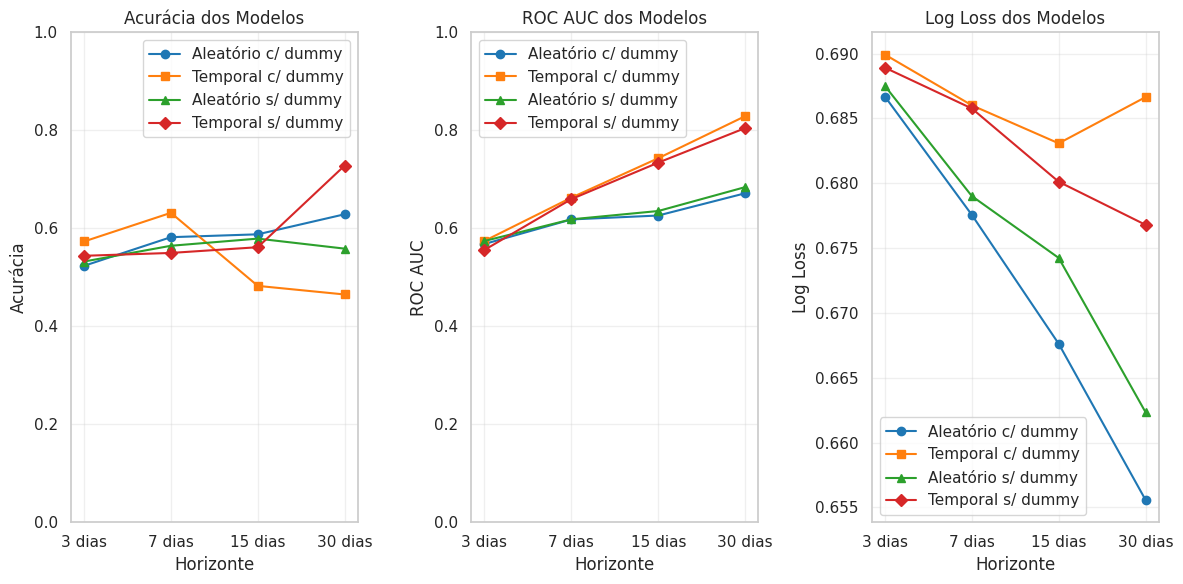


Legenda:
Acc = Acurácia | AUC = ROC AUC | LogLoss = Log Loss
c/ dummy = com variável dicotômica | s/ dummy = sem variável dicotômica
Aleatório = divisão aleatória | Temporal = divisão temporal (série temporal)


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparando os dados para a tabela de comparação
comparacao = []
for horizon in horizons:
    linha = {
        'Horizonte': f'{horizon[:-1]} dias',
        'Aleatório c/ dummy': results[horizon]['accuracy'] if horizon in results else None,
        'Temporal c/ dummy': results_temporal[horizon]['accuracy'] if horizon in results_temporal else None,
        'Aleatório s/ dummy': results_no_dummy[horizon]['accuracy'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy': results_temporal_no_dummy[horizon]['accuracy'] if horizon in results_temporal_no_dummy else None,
        'Aleatório c/ dummy AUC': results[horizon]['roc_auc'] if horizon in results else None,
        'Temporal c/ dummy AUC': results_temporal[horizon]['roc_auc'] if horizon in results_temporal else None,
        'Aleatório s/ dummy AUC': results_no_dummy[horizon]['roc_auc'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy AUC': results_temporal_no_dummy[horizon]['roc_auc'] if horizon in results_temporal_no_dummy else None,
        'Aleatório c/ dummy LogLoss': results[horizon]['log_loss'] if horizon in results else None,
        'Temporal c/ dummy LogLoss': results_temporal[horizon]['log_loss'] if horizon in results_temporal else None,
        'Aleatório s/ dummy LogLoss': results_no_dummy[horizon]['log_loss'] if horizon in results_no_dummy else None,
        'Temporal s/ dummy LogLoss': results_temporal_no_dummy[horizon]['log_loss'] if horizon in results_temporal_no_dummy else None,
    }
    comparacao.append(linha)

comparacao_df = pd.DataFrame(comparacao)

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Gráfico de Acurácia
plt.subplot(1, 3, 1)
for col, label, color, marker in zip([
    'Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy'],
    ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy'],
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    ['o', 's', '^', 'D']):
    plt.plot(comparacao_df['Horizonte'], comparacao_df[col], label=label, marker=marker, color=color)
plt.title('Acurácia dos Modelos')
plt.ylabel('Acurácia')
plt.xlabel('Horizonte')
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Gráfico de ROC AUC
plt.subplot(1, 3, 2)
for col, label, color, marker in zip([
    'Aleatório c/ dummy AUC', 'Temporal c/ dummy AUC', 'Aleatório s/ dummy AUC', 'Temporal s/ dummy AUC'],
    ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy'],
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    ['o', 's', '^', 'D']):
    plt.plot(comparacao_df['Horizonte'], comparacao_df[col], label=label, marker=marker, color=color)
plt.title('ROC AUC dos Modelos')
plt.ylabel('ROC AUC')
plt.xlabel('Horizonte')
plt.legend()
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

# Gráfico de Log Loss
plt.subplot(1, 3, 3)
for col, label, color, marker in zip([
    'Aleatório c/ dummy LogLoss', 'Temporal c/ dummy LogLoss', 'Aleatório s/ dummy LogLoss', 'Temporal s/ dummy LogLoss'],
    ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy'],
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
    ['o', 's', '^', 'D']):
    plt.plot(comparacao_df['Horizonte'], comparacao_df[col], label=label, marker=marker, color=color)
plt.title('Log Loss dos Modelos')
plt.ylabel('Log Loss')
plt.xlabel('Horizonte')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLegenda:")
print("Acc = Acurácia | AUC = ROC AUC | LogLoss = Log Loss")
print("c/ dummy = com variável dicotômica | s/ dummy = sem variável dicotômica")
print("Aleatório = divisão aleatória | Temporal = divisão temporal (série temporal)")

#### Matrizes de Confusão por Horizonte Temporal

Agora vamos analisar as matrizes de confusão para cada horizonte temporal (3, 7, 15 e 30 dias), comparando todos os 4 modelos em cada horizonte.


MATRIZES DE CONFUSÃO - HORIZONTE 3 DIAS


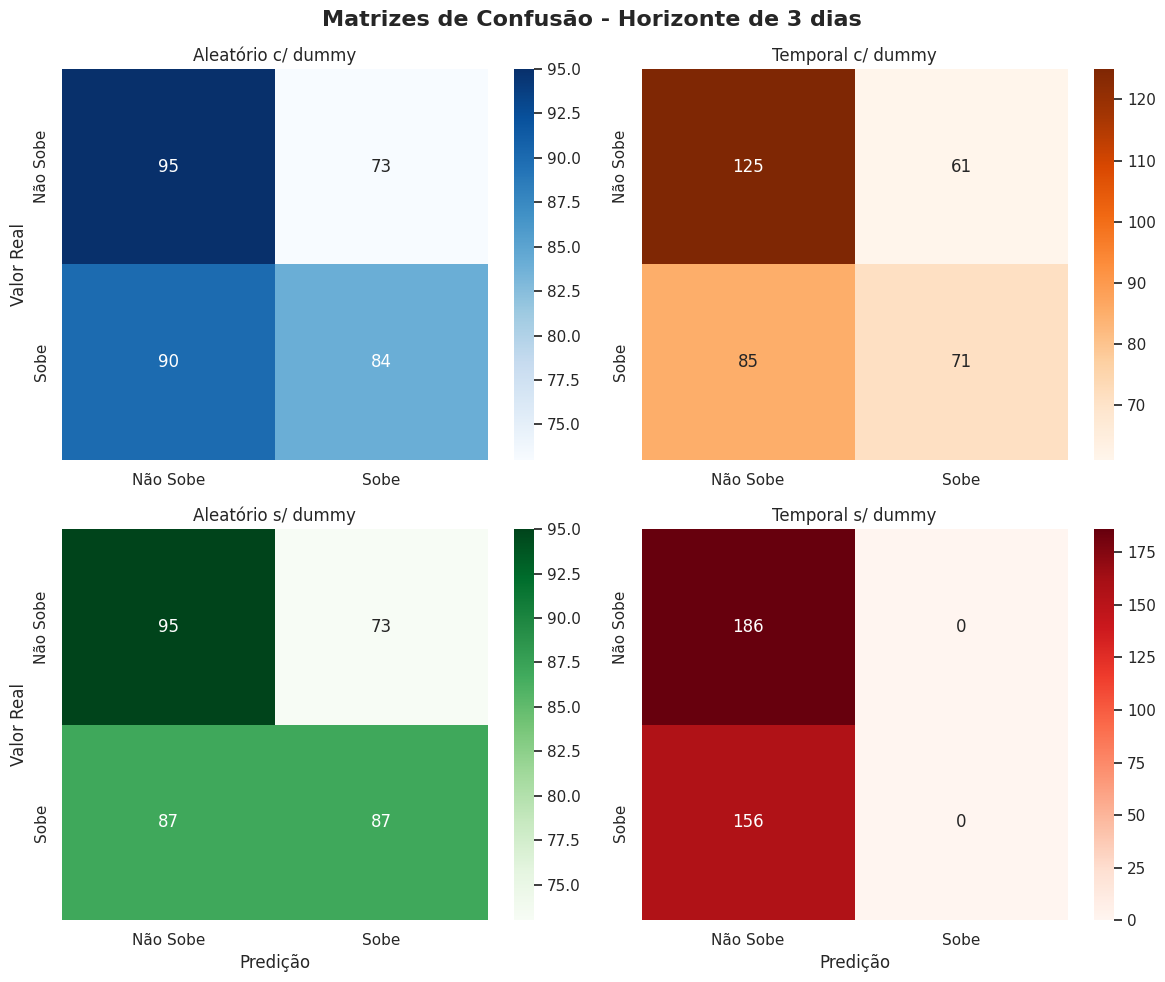

Aleatório c/ dummy - 3d: Acc=0.523, Prec=0.535, Rec=0.483, F1=0.508
Temporal c/ dummy - 3d: Acc=0.573, Prec=0.538, Rec=0.455, F1=0.493
Aleatório s/ dummy - 3d: Acc=0.532, Prec=0.544, Rec=0.500, F1=0.521
Temporal s/ dummy - 3d: Acc=0.544, Prec=0.000, Rec=0.000, F1=0.000

------------------------------------------------------------

MATRIZES DE CONFUSÃO - HORIZONTE 7 DIAS


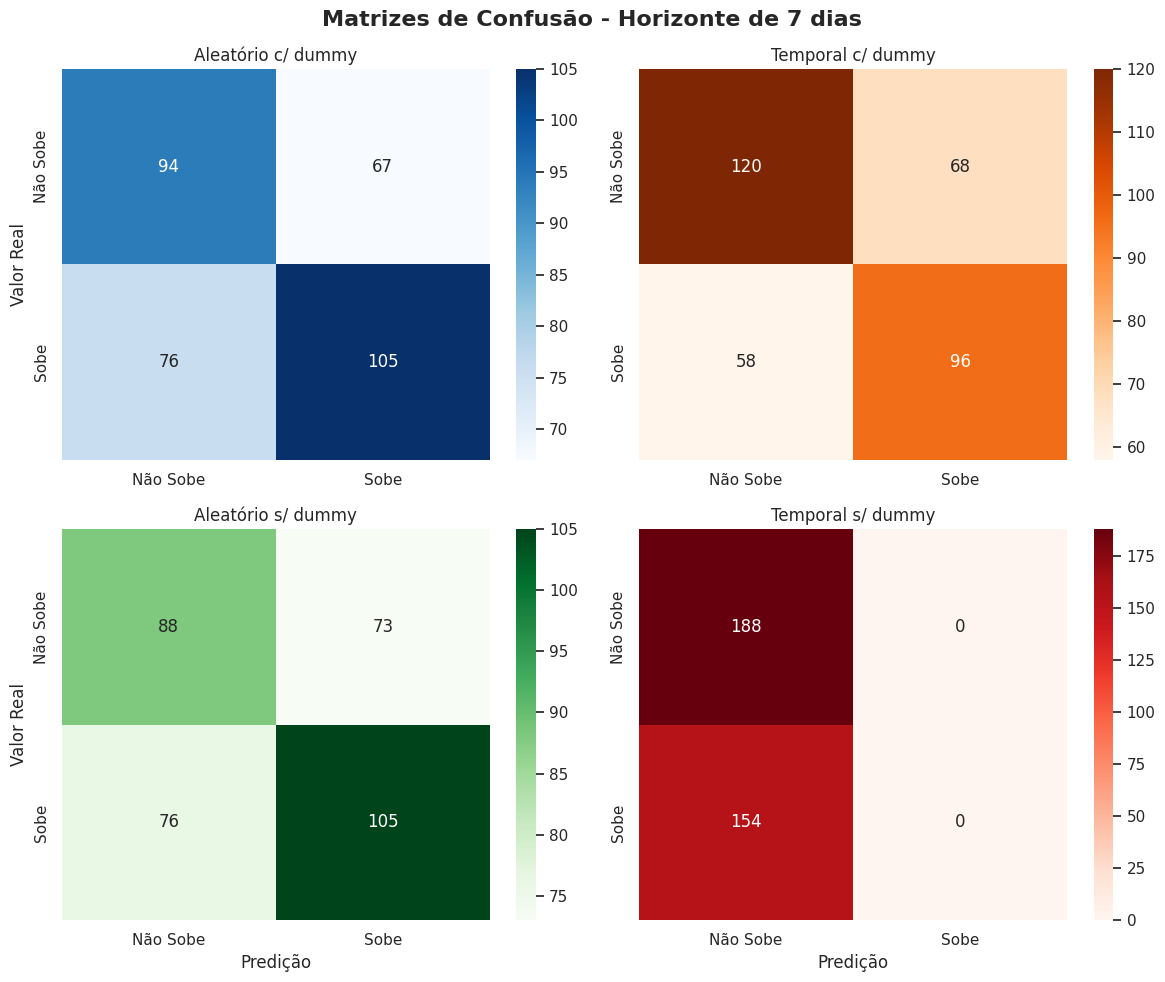

Aleatório c/ dummy - 7d: Acc=0.582, Prec=0.610, Rec=0.580, F1=0.595
Temporal c/ dummy - 7d: Acc=0.632, Prec=0.585, Rec=0.623, F1=0.604
Aleatório s/ dummy - 7d: Acc=0.564, Prec=0.590, Rec=0.580, F1=0.585
Temporal s/ dummy - 7d: Acc=0.550, Prec=0.000, Rec=0.000, F1=0.000

------------------------------------------------------------

MATRIZES DE CONFUSÃO - HORIZONTE 15 DIAS


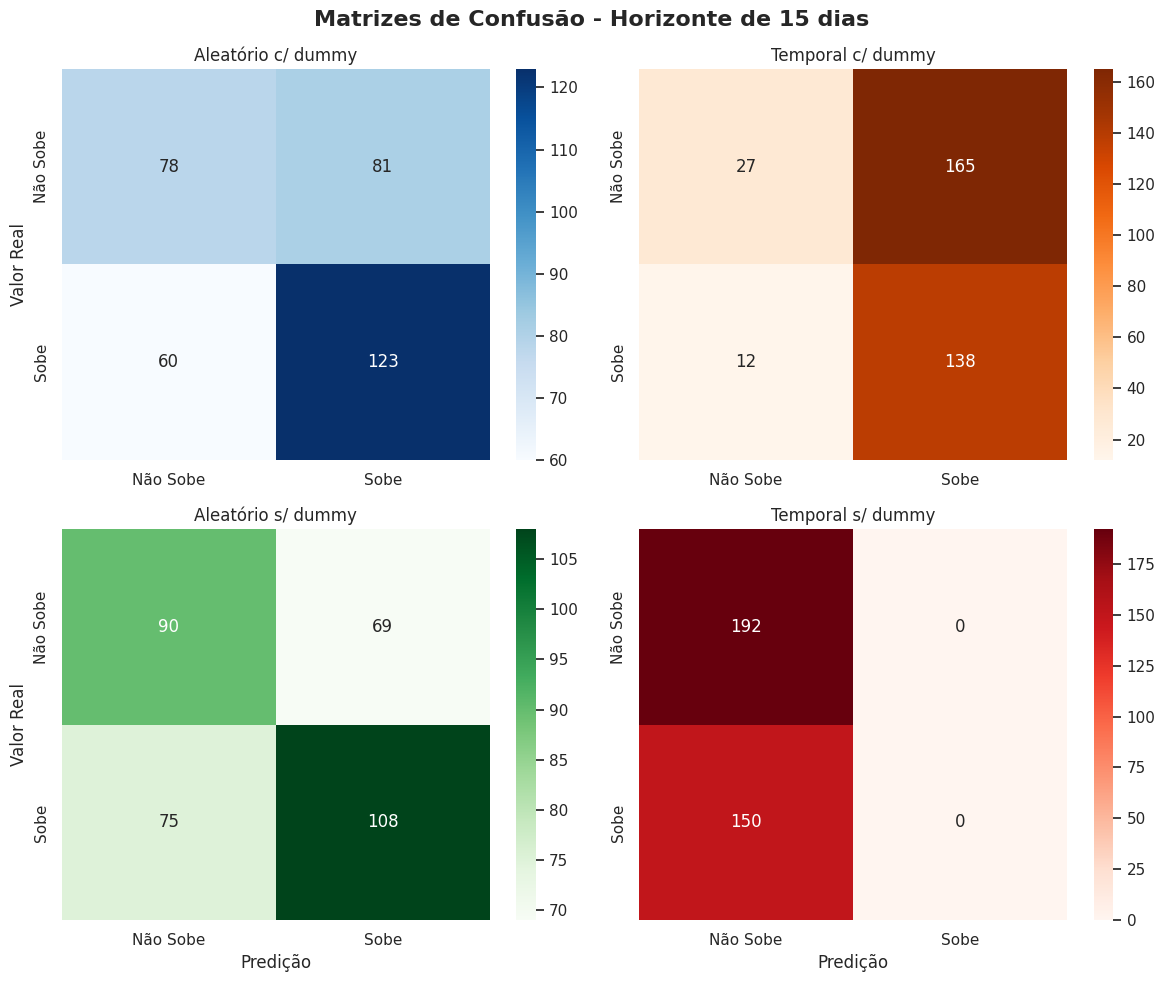

Aleatório c/ dummy - 15d: Acc=0.588, Prec=0.603, Rec=0.672, F1=0.636
Temporal c/ dummy - 15d: Acc=0.482, Prec=0.455, Rec=0.920, F1=0.609
Aleatório s/ dummy - 15d: Acc=0.579, Prec=0.610, Rec=0.590, F1=0.600
Temporal s/ dummy - 15d: Acc=0.561, Prec=0.000, Rec=0.000, F1=0.000

------------------------------------------------------------

MATRIZES DE CONFUSÃO - HORIZONTE 30 DIAS


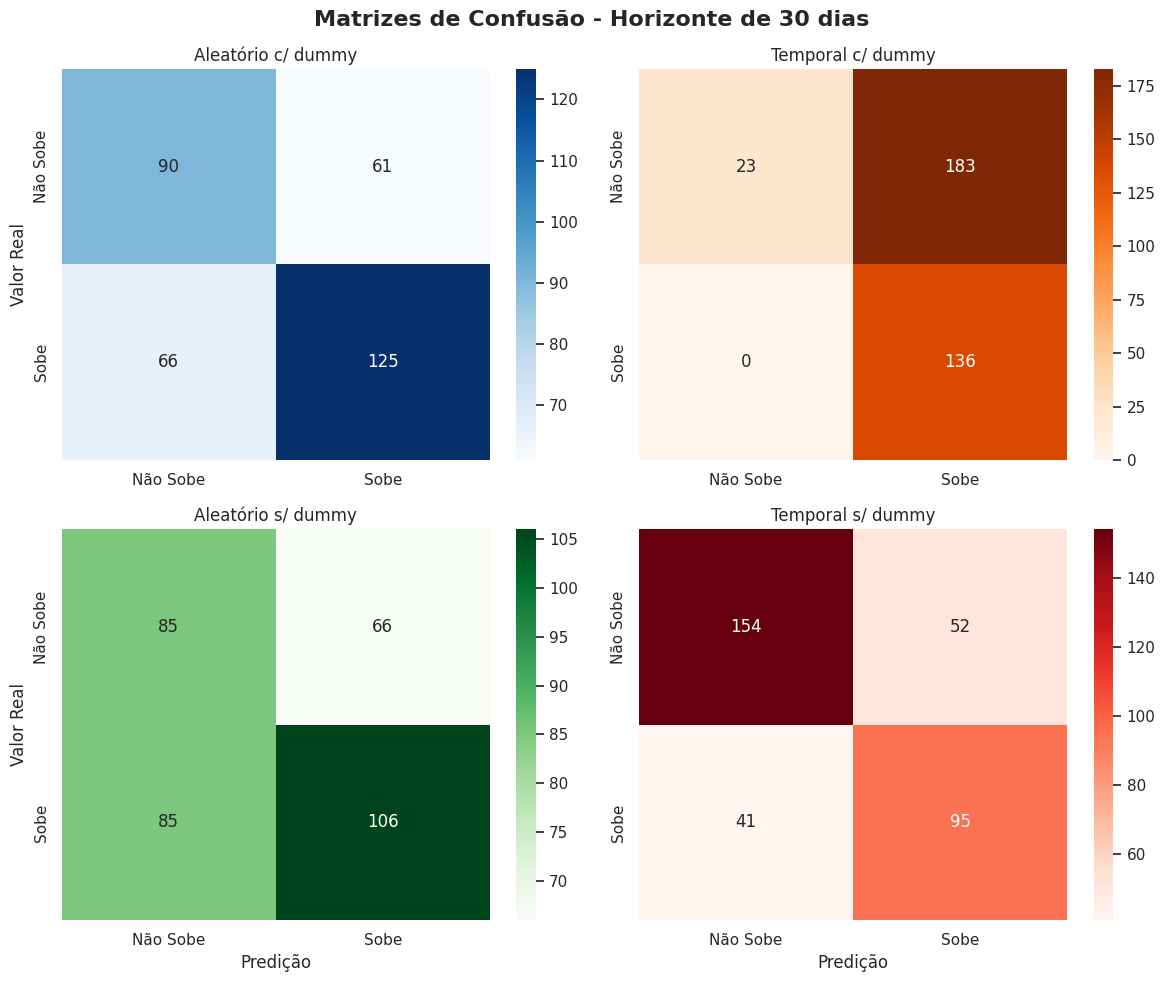

Aleatório c/ dummy - 30d: Acc=0.629, Prec=0.672, Rec=0.654, F1=0.663
Temporal c/ dummy - 30d: Acc=0.465, Prec=0.426, Rec=1.000, F1=0.598
Aleatório s/ dummy - 30d: Acc=0.558, Prec=0.616, Rec=0.555, F1=0.584
Temporal s/ dummy - 30d: Acc=0.728, Prec=0.646, Rec=0.699, F1=0.671

------------------------------------------------------------

RESUMO GERAL DAS MATRIZES DE CONFUSÃO
- Foram criados 4 gráficos separados, um para cada horizonte temporal (3, 7, 15, 30 dias)
- Em cada gráfico, as 4 posições representam os tipos de modelo:
  • Superior esquerda: Aleatório com dummy_period (Azul)
  • Superior direita: Temporal com dummy_period (Laranja)
  • Inferior esquerda: Aleatório sem dummy_period (Verde)
  • Inferior direita: Temporal sem dummy_period (Vermelho)

- Valores na matriz:
  • Superior esquerda: Verdadeiros Negativos (previu 'Não Sobe' e estava correto)
  • Superior direita: Falsos Positivos (previu 'Sobe' mas estava errado)
  • Inferior esquerda: Falsos Negativos (previu 'Não Sobe' ma

In [42]:
# Gerando matrizes de confusão para todos os horizontes temporais
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cores para cada modelo
colors = ['Blues', 'Oranges', 'Greens', 'Reds']
model_names = ['Aleatório c/ dummy', 'Temporal c/ dummy', 'Aleatório s/ dummy', 'Temporal s/ dummy']

# Criando 4 gráficos separados, um para cada horizonte temporal
for h_idx, horizon in enumerate(horizons):
    target_col = f'target_{horizon}'
    y_base = df_process[target_col].copy()
    
    print(f"\n{'='*50}")
    print(f"MATRIZES DE CONFUSÃO - HORIZONTE {horizon[:-1]} DIAS")
    print(f"{'='*50}")
    
    # Criando um gráfico 2x2 para este horizonte
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Matrizes de Confusão - Horizonte de {horizon[:-1]} dias', fontsize=16, fontweight='bold')
    
    # 1. Modelo Aleatório com dummy_period
    mask1 = ~(X_scaled_df.isnull().any(axis=1) | y_base.isnull())
    X_clean1 = X_scaled_df[mask1]
    y_clean1 = y_base[mask1]
    X_train1, X_test1, y_train1, y_test1 = train_test_split(
        X_clean1, y_clean1, test_size=0.2, random_state=42, stratify=y_clean1
    )
    y_pred1 = models[horizon].predict(X_test1)
    cm1 = confusion_matrix(y_test1, y_pred1)
    
    sns.heatmap(cm1, annot=True, fmt='d', cmap=colors[0], ax=axes[0, 0],
                xticklabels=['Não Sobe', 'Sobe'], yticklabels=['Não Sobe', 'Sobe'])
    axes[0, 0].set_title(f'{model_names[0]}')
    axes[0, 0].set_ylabel('Valor Real')
    
    # 2. Modelo Temporal com dummy_period
    mask2 = ~(X_scaled_df.isnull().any(axis=1) | y_base.isnull())
    X_clean2 = X_scaled_df[mask2]
    y_clean2 = y_base[mask2]
    split_idx = int(0.8 * len(X_clean2))
    X_test2 = X_clean2.iloc[split_idx:]
    y_test2 = y_clean2.iloc[split_idx:]
    y_pred2 = models_temporal[horizon].predict(X_test2)
    cm2 = confusion_matrix(y_test2, y_pred2)
    
    sns.heatmap(cm2, annot=True, fmt='d', cmap=colors[1], ax=axes[0, 1],
                xticklabels=['Não Sobe', 'Sobe'], yticklabels=['Não Sobe', 'Sobe'])
    axes[0, 1].set_title(f'{model_names[1]}')
    
    # 3. Modelo Aleatório sem dummy_period
    mask3 = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y_base.isnull())
    X_clean3 = X_scaled_df_no_dummy[mask3]
    y_clean3 = y_base[mask3]
    X_train3, X_test3, y_train3, y_test3 = train_test_split(
        X_clean3, y_clean3, test_size=0.2, random_state=42, stratify=y_clean3
    )
    
    # Retreinar o modelo sem dummy para garantir consistência
    model_temp3 = LogisticRegression(random_state=42, max_iter=1000)
    model_temp3.fit(X_train3, y_train3)
    y_pred3 = model_temp3.predict(X_test3)
    cm3 = confusion_matrix(y_test3, y_pred3)
    
    sns.heatmap(cm3, annot=True, fmt='d', cmap=colors[2], ax=axes[1, 0],
                xticklabels=['Não Sobe', 'Sobe'], yticklabels=['Não Sobe', 'Sobe'])
    axes[1, 0].set_title(f'{model_names[2]}')
    axes[1, 0].set_ylabel('Valor Real')
    axes[1, 0].set_xlabel('Predição')
    
    # 4. Modelo Temporal sem dummy_period
    mask4 = ~(X_scaled_df_no_dummy.isnull().any(axis=1) | y_base.isnull())
    X_clean4 = X_scaled_df_no_dummy[mask4]
    y_clean4 = y_base[mask4]
    split_idx4 = int(0.8 * len(X_clean4))
    X_train4 = X_clean4.iloc[:split_idx4]
    X_test4 = X_clean4.iloc[split_idx4:]
    y_train4 = y_clean4.iloc[:split_idx4]
    y_test4 = y_clean4.iloc[split_idx4:]
    
    # Retreinar o modelo temporal sem dummy para garantir consistência
    model_temp4 = LogisticRegression(random_state=42, max_iter=1000)
    model_temp4.fit(X_train4, y_train4)
    y_pred4 = model_temp4.predict(X_test4)
    cm4 = confusion_matrix(y_test4, y_pred4)
    
    sns.heatmap(cm4, annot=True, fmt='d', cmap=colors[3], ax=axes[1, 1],
                xticklabels=['Não Sobe', 'Sobe'], yticklabels=['Não Sobe', 'Sobe'])
    axes[1, 1].set_title(f'{model_names[3]}')
    axes[1, 1].set_xlabel('Predição')
    
    plt.tight_layout()
    plt.show()
    
    # Análise resumida para cada horizonte
    modelos_horizon = [
        (f"{model_names[0]} - {horizon[:-1]}d", cm1, y_test1, y_pred1),
        (f"{model_names[1]} - {horizon[:-1]}d", cm2, y_test2, y_pred2),
        (f"{model_names[2]} - {horizon[:-1]}d", cm3, y_test3, y_pred3),
        (f"{model_names[3]} - {horizon[:-1]}d", cm4, y_test4, y_pred4)
    ]
    
    for nome, cm, y_true, y_pred in modelos_horizon:
        # Calculando métricas
        tn, fp, fn, tp = cm.ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        print(f"{nome}: Acc={accuracy:.3f}, Prec={precision:.3f}, Rec={recall:.3f}, F1={f1:.3f}")
    
    print(f"\n{'-'*60}")  # Separador entre horizontes

print(f"\n{'='*80}")
print("RESUMO GERAL DAS MATRIZES DE CONFUSÃO")
print(f"{'='*80}")
print("- Foram criados 4 gráficos separados, um para cada horizonte temporal (3, 7, 15, 30 dias)")
print("- Em cada gráfico, as 4 posições representam os tipos de modelo:")
print("  • Superior esquerda: Aleatório com dummy_period (Azul)")
print("  • Superior direita: Temporal com dummy_period (Laranja)")
print("  • Inferior esquerda: Aleatório sem dummy_period (Verde)")
print("  • Inferior direita: Temporal sem dummy_period (Vermelho)")
print("\n- Valores na matriz:")
print("  • Superior esquerda: Verdadeiros Negativos (previu 'Não Sobe' e estava correto)")
print("  • Superior direita: Falsos Positivos (previu 'Sobe' mas estava errado)")
print("  • Inferior esquerda: Falsos Negativos (previu 'Não Sobe' mas deveria ter previsto 'Sobe')")
print("  • Inferior direita: Verdadeiros Positivos (previu 'Sobe' e estava correto)")
print("\n- Vantagem desta organização:")
print("  • Permite comparação detalhada dos 4 modelos para cada horizonte específico")
print("  • Facilita identificação de padrões por período temporal")
print("  • Melhor legibilidade dos valores nas matrizes")